In [1]:
#-----------------
#IMPORT LIBRARIES
#-----------------
install.packages(c("stargazer","ggplot2"))
library(stargazer)
library(ggplot2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 




DATA PREPARATION

In [16]:
#----------------------
#Parameters Setting
#----------------------

p1 <- seq(1,10,by=1)

M <- 100
alpha <- 0.35
beta <- 1-alpha

p1_fix <- 3
p2_fix <- 5

#-------------------------------------------
# MARSHALLAN DEMAND FUNCTION FOR GOODS
# x1,x2 = Quantity demanded of good1,good2
# M = Consumers total budget or Income
# p1,p2 = Price of good1, good2
# alpha = Elasticity of utility with respect to good 1
# beta =  Elasticity of utility with respect to good 2
# x1 = alpha * M/p1,x2 = beta * M/p2
#-------------------------------------------

x1 <- (alpha * M)/p1
x2_fix <- (beta * M)/p2_fix

df_demand <- data.frame(
  p1 = p1,
  x1 = x1,
  x2 = x2_fix
)

#-----------------------
# MARSHALLAN DEMAND
#----------------------

x1_star <- (alpha * M)/p1_fix
x2_star <- (beta * M)/p2_fix

#-------------------------------------------
# BUDGET CONSTRAINT
# x2 = (M - p1*x1)/p2
#-------------------------------------------
x1_seq <- seq(0.1, M/p1_fix, by = 0.1)
x2_budget <- (M - p1_fix*x1_seq)/p2_fix

df_budget <- data.frame(
  x1_seq = x1_seq,
  x2_budget = x2_budget
)

#-------------------------------------------
# UTILITY AT OPTIMUM
# U* = x1^alpha * x2^beta
#-------------------------------------------
u_star <- (x1_star^alpha)*(x2_star^beta)

#-------------------------------------------
# INDIFFERENCE CURVE
#-------------------------------------------
x2_indiff <- (u_star/(x1_seq^alpha)) ^(1/beta)

df_indifference <- data.frame(
  x1_seq = x1_seq,
  x2_indiff = x2_indiff
)

df_optimal <- data.frame(
  x = x1_star,
  y = x2_star
)

cat("Cobb douglas demand table\n")
print(df_demand)

cat("\nBudget table\n")
print(head(df_budget,10))

cat("\nIndiference\n")
print(head(df_indifference,10))

cat("\nOptimal\n")
print(head(df_optimal,10))

Cobb douglas demand table
   p1        x1 x2
1   1 35.000000 13
2   2 17.500000 13
3   3 11.666667 13
4   4  8.750000 13
5   5  7.000000 13
6   6  5.833333 13
7   7  5.000000 13
8   8  4.375000 13
9   9  3.888889 13
10 10  3.500000 13

Budget table
   x1_seq x2_budget
1     0.1     19.94
2     0.2     19.88
3     0.3     19.82
4     0.4     19.76
5     0.5     19.70
6     0.6     19.64
7     0.7     19.58
8     0.8     19.52
9     0.9     19.46
10    1.0     19.40

Indiference
   x1_seq x2_indiff
1     0.1 168.62218
2     0.2 116.09717
3     0.3  93.32613
4     0.4  79.93345
5     0.5  70.88368
6     0.6  64.25548
7     0.7  59.13736
8     0.8  55.03456
9     0.9  51.65256
10    1.0  48.80375

Optimal
         x  y
1 11.66667 13


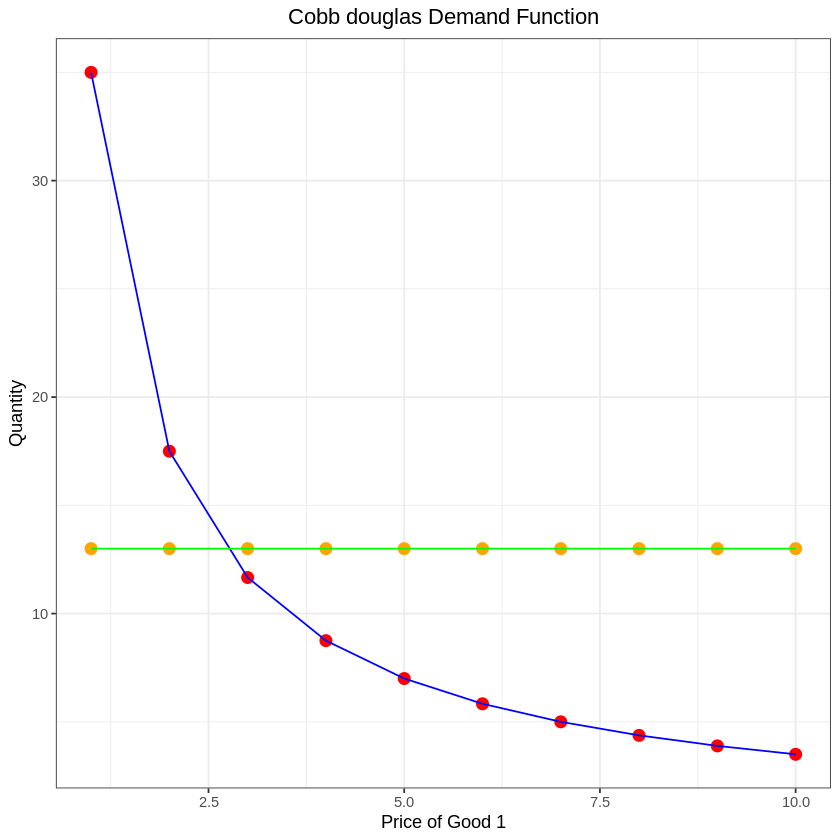

In [24]:
#COBB DOUGLAS GRAPH
ggplot(data=df_demand,aes(x=p1))+
  geom_point(aes(y=x1),color="red",size=3) +
  geom_line(aes(y=x1),color="blue") +
  geom_point(aes(y=x2),color="orange",size=3) +
  geom_line(aes(y=x2),color="green") +
  theme_bw() +
  labs(title="Cobb douglas Demand Function",
       x="Price of Good 1",
       y="Quantity")+
  theme(plot.title = element_text(hjust= 0.5))

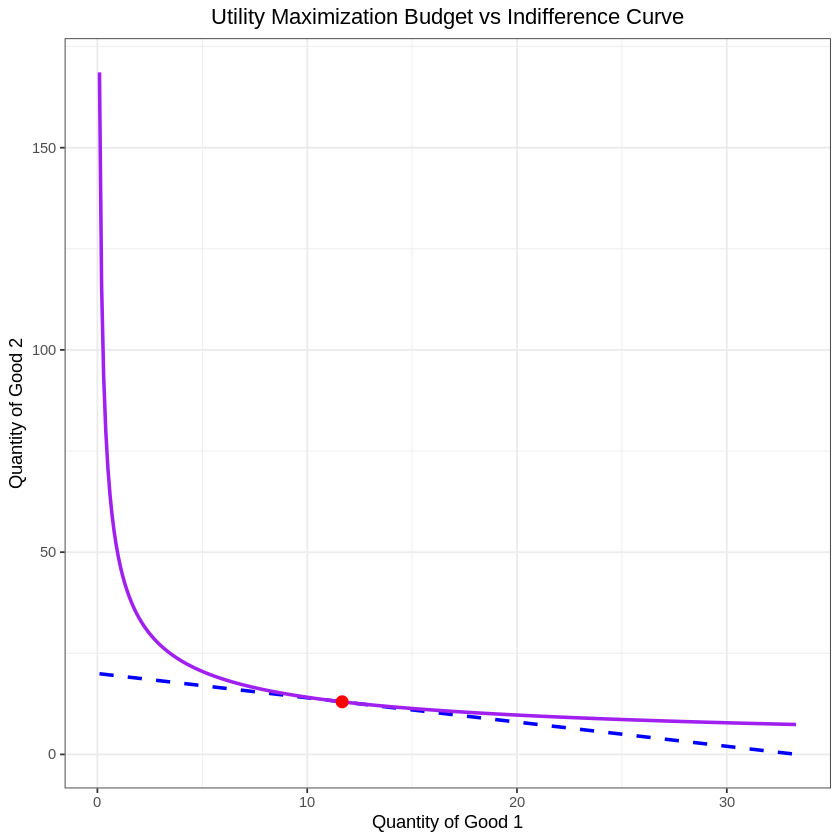

In [25]:
#UTILITY MAXIMIZATION AND INDIFFERENCE CURVE
ggplot() +
  geom_line(data = df_budget,aes(x = x1_seq, y = x2_budget), color = "blue", linetype = "dashed", size = 1) +
    geom_line(data=df_indifference,aes(x = x1_seq, y = x2_indiff), color = "purple", size = 1) +
     geom_point(data=df_optimal,aes(x = x, y = y), color="red", size=3) +
  theme_bw() +
  labs(title = "Utility Maximization Budget vs Indifference Curve",
       x = "Quantity of Good 1",
       y = "Quantity of Good 2") +


  theme(plot.title = element_text(hjust = 0.5))